In [ ]:
import os
import sys
from os import path
sys.path.insert(0, "/home/thomasb")
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
#import sat_utils as su
import importlib
#from albatros_analysis.src.utils import orbcomm_utils as outils
from albatros_analysis.src.utils import baseband_utils as butils
#import helper_discrepancies as hd
#importlib.reload(su)
importlib.reload(butils)
#importlib.reload(hd)

<module 'albatros_analysis.src.utils.baseband_utils' from '/home/thomasb/albatros_analysis/src/utils/baseband_utils.py'>

# PART 1 Satellite Detection

## i) Get Batches

We first want to know what periods of time data is continuously present. These are called BATCHES, and usually last all day unless there is an unexpected interruption (which can happen).

In [2]:
#all the antenna we want to look at
# ant_path_list =['/scratch/mohanagr/summer_2025/baseband/mars1',
#                 '/scratch/mohanagr/summer_2025/baseband/mars2',
#                 '/scratch/mohanagr/summer_2025/baseband/mars3',
#                 '/scratch/mohanagr/summer_2025/baseband/mars4',
#                 '/scratch/mohanagr/summer_2025/baseband/mars5',
#                 '/scratch/mohanagr/summer_2025/baseband/mars6',
#                 '/scratch/mohanagr/summer_2025/baseband/mars7',
#                 '/scratch/mohanagr/summer_2025/baseband/mars8']

ant_path_list = [
    '/project/rrg-sievers/albatros/mars/202507/mars1/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars2/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars3/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars4/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars5',
    '/project/rrg-sievers/albatros/mars/202507/mars6/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars7/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars8/baseband'
]

#big interval to catch everything
interval_start, interval_end = 1761980000, 1762500000

In [ ]:
#get_present_files returns an array that tells you when files are present
arr, fig1 = butils.get_present_files(interval_start, interval_end, ant_path_list)

NameError: name 'butils' is not defined

In [ ]:
#runs give you timestamps within which there is active data from every desired antenna
runs = butils.get_simul_files(arr, 1761980000, 10, [1, 3, 4, 5, 6, 7])
print(runs)

NameError: name 'butils' is not defined

In [13]:
for r in runs:
    print(r[0], r[1]-r[0])

1762000060 12750
1762012960 22180
1762035170 480
1762035680 50
1762035780 1070
1762036880 110
1762037020 270
1762037320 61900
1762099360 86260
1762185760 86270
1762272160 86270
1762358570 22030
1762380630 1980
1762382640 17360


In [5]:
runs = butils.get_simul_files(arr, interval_start, 10, [0])
print(runs)
nzeros = int((interval_end-interval_start)/10)
print(nzeros)
presence = np.zeros(nzeros+1)
times = np.arange(interval_start, interval_end + 10, 10)
times_real = [datetime.fromtimestamp(t, tz=timezone.utc).strftime('%d/%m, %H:%M:%S') for t in times]

for start, end in runs:
    presence[(times >= start) & (times <= end)] = 1

print(len(runs)) 

[[1762006230, 1762007680], [1762008110, 1762010200], [1762010590, 1762012840], [1762013220, 1762015480], [1762015840, 1762018260], [1762018610, 1762020860], [1762021240, 1762023440], [1762023810, 1762026180], [1762026540, 1762028900], [1762029260, 1762031620], [1762031950, 1762034310], [1762034830, 1762037190], [1762037530, 1762042680], [1762043060, 1762045480], [1762045800, 1762048210], [1762048560, 1762051080], [1762051430, 1762053730], [1762054070, 1762056490], [1762056850, 1762059260], [1762059620, 1762062140], [1762062430, 1762065060], [1762065370, 1762067780], [1762068070, 1762070650], [1762070950, 1762073420], [1762073700, 1762076280], [1762076610, 1762079350], [1762079680, 1762082090], [1762082440, 1762085120], [1762085410, 1762087990], [1762088300, 1762090760], [1762091050, 1762092870], [1762093280, 1762094300], [1762094610, 1762097020], [1762097340, 1762099210], [1762099350, 1762099880], [1762100190, 1762102610], [1762102940, 1762105460], [1762105780, 1762108400], [1762108700

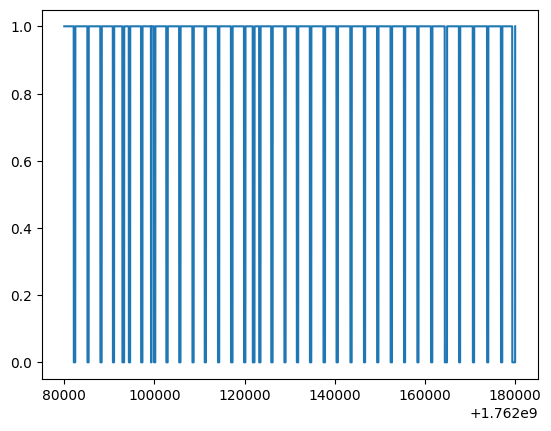

In [6]:
plt.plot(times[10000:20000], presence[10000:20000])

In [20]:
names_file = [
    'ALB1',
    'ALB2',
    'ALB4',
    'ALB5',
    'ALB6',
    'ALB7',
    'ALB8'
]

names_actual = [
    "Antenna 1",
    "Antenna 2",
    "Antenna 4",
    "Antenna 5",
    "Antenna 6",
    "Antenna 7",
    "Antenna 8",
]

coords = [
    [79.41716147, -90.76723869, 187.9577],
    [79.41719805, -90.75873919, 183.0684],
    [79.38845641, -91.01920296, 25.1938],
    [79.41830257, -90.66739545, 59.6242],
    [79.39798424, -90.79984241, 41.699],
    [79.41147412, -90.69526613, 31.6314],
    [79.44375769, -90.71820263, 414.9131],
]
nant = len(names_file)

In [8]:
for i, (t_start, t_end) in enumerate(runs):
    file = {}

    antennas = {}
    for j in range(nant):
        antennas[names_file[j]] = {}
        antennas[names_file[j]]["name"] = names_actual[j]
        antennas[names_file[j]]["path"] = ant_path_list[j]
        antennas[names_file[j]]["coordinates"] = coords[j]
    file['antennas'] = antennas
    file["correlation"] = {
        "start_timestamp": t_start,
        "end_timestamp": t_end,
        "vis_acclen": 30000,
        "coarse_acclen": 3000000,
        "osamp": 64,
        "pfb_size": 65536,
        "new_acclen": 1024
    }
    file["frequency"] = {
        "start_channel": 1834,
        "end_channel": 1852
    }
    print(file)
    
    with open(os.path.join('/home/thomasb/albatros_analysis/scripts/orbcomm/config', f'config_nov25_batch{i+1}.json'), 'w') as f:
        json.dump(file, f, indent=4)

{'antennas': {'ALB1': {'name': 'Antenna 1', 'path': '/project/rrg-sievers/albatros/mars/202507/mars1/baseband', 'coordinates': [79.41716147, -90.76723869, 187.9577]}, 'ALB2': {'name': 'Antenna 2', 'path': '/project/rrg-sievers/albatros/mars/202507/mars2/baseband', 'coordinates': [79.41719805, -90.75873919, 183.0684]}, 'ALB4': {'name': 'Antenna 4', 'path': '/project/rrg-sievers/albatros/mars/202507/mars4/baseband', 'coordinates': [79.38845641, -91.01920296, 25.1938]}, 'ALB5': {'name': 'Antenna 5', 'path': '/project/rrg-sievers/albatros/mars/202507/mars5/baseband', 'coordinates': [79.41830257, -90.66739545, 59.6242]}, 'ALB6': {'name': 'Antenna 6', 'path': '/project/rrg-sievers/albatros/mars/202507/mars6/baseband', 'coordinates': [79.39798424, -90.79984241, 41.699]}, 'ALB7': {'name': 'Antenna 7', 'path': '/project/rrg-sievers/albatros/mars/202507/mars7/baseband', 'coordinates': [79.41147412, -90.69526613, 31.6314]}, 'ALB8': {'name': 'Antenna 8', 'path': '/project/rrg-sievers/albatros/mars

We run satdet for each batch individually, since spectra reset between days (so beteween most batches). Spectrum alignment is therefore only valid within a batch.

The next step is to run satdet, which is fully discussed elsewhere.

## ii) After Satdet

Satdet will give you SNR against time throughout a batch. It also gives you the correct spectrum alignment (all relative to the reference antenna). As an example, consider batch 1 for MARS1 - MARS2

In [ ]:
#define some paths and a cutoff
path1 = '/scratch/thomasb/satdet_data_1753132820_3M_len_67200_1769207603.json'
start1 = 1753132820
end1 = 1753132820 + 67200
ant_name = 'Antenna 2'

/home/thomasb/albatros_analysis/scripts/orbcomm/sat_utils.py:385: RuntimeWarning: divide by zero encountered in log10
  snr_db = np.where(snrarr > 0, 10 * np.log10(snrarr), 0.0)


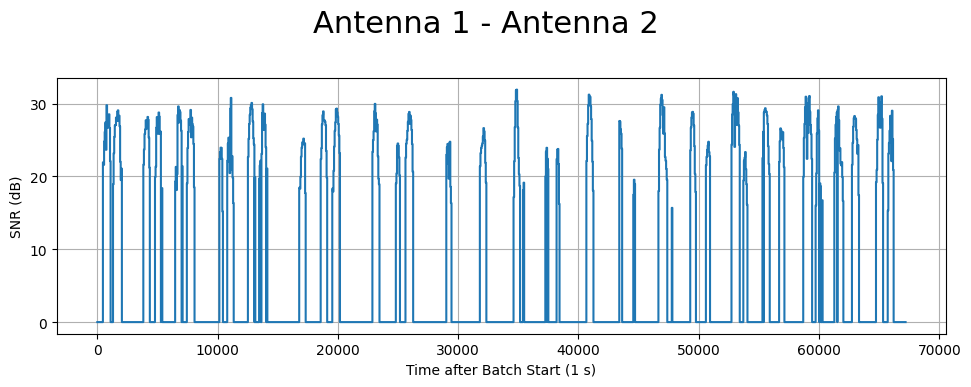

In [ ]:
importlib.reload(su)
time_arr, snr_arr, fig2 = su.snr_times_single(path1, start1, end1, ant_name)

If we want to compare two batches, we can plot two batches on top of each other. This function automatically lines up the axes so that horizontal lines coincide with LST to the nearest second. The x axis tick marks are zero for the individual batch's start time. We now do this for batch 1 and batch 2

In [ ]:
#define a second path
path2 = '/scratch/thomasb/satdet_data_1753200150_3M_len_86260_1769307199.json'
start2 = 1753200150
end2 = 1753200150 + 86260

start lsts [169.20739175867078, 90.51715899442962]
min lst 90.51715899442962
Front padding triggered at 18885
max array len 86261
pad 175
pad 0


/home/thomasb/albatros_analysis/scripts/orbcomm/sat_utils.py:385: RuntimeWarning: divide by zero encountered in log10
  snr_db = np.where(snrarr > 0, 10 * np.log10(snrarr), 0.0)


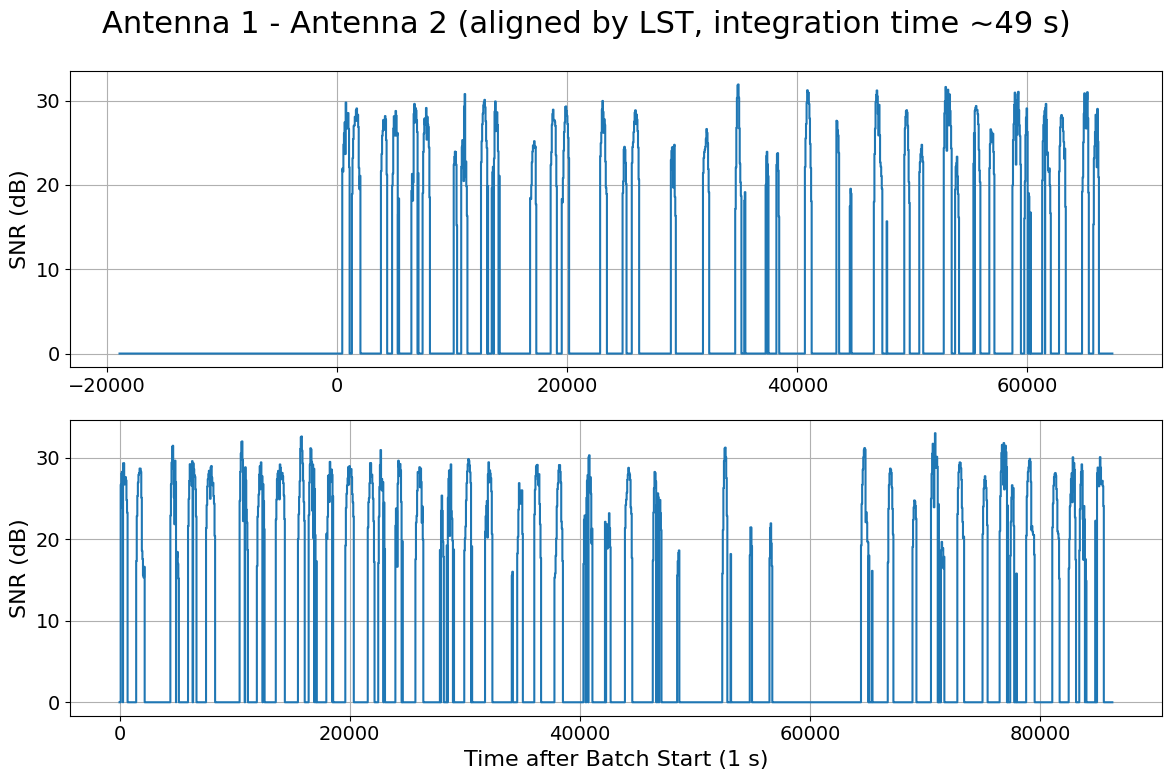

In [ ]:
secs, times, fig3 = su.snr_times_many([path1, path2], [start1, start2], [end1, end2], ant_name)

So in this example, the pulses do not overlap perfectly in LST so they are offset.

In fact, we can overlap arbitrarily many batches for visibility purposes.

In [3]:
bpath1 = '/scratch/thomasb/satdet_data_1753132820_3M_len_67200_1769207603.json'
bstart1 = 1753132820
bend1 = 1753132820 + 67200

bpath2 = '/scratch/thomasb/satdet_data_1753200150_3M_len_86260_1769307199.json'
bstart2 = 1753200150
bend2 = 1753286400

bpath3 = '/scratch/thomasb/satdet_data_1753286530_3M_len_9500_1769554690.json'
bstart3 = 1753286530
bend3 = 1753286530 + 9500

bpath4 = '/scratch/thomasb/satdet_data_1753300680_3M_len_11240_1769554685.json'
bstart4 = 1753300680
bend4 = 1753300680 + 11240

ant_name = 'Antenna 2'

start lsts [169.20739175867078, 90.51715899442962, 91.41924829499285, 150.53900473424972]
min lst 90.51715899442962
Front padding triggered at 18885
Front padding triggered at 216
Front padding triggered at 14405
max array len 86251
pad 165
pad 0
pad 76534
pad 60605


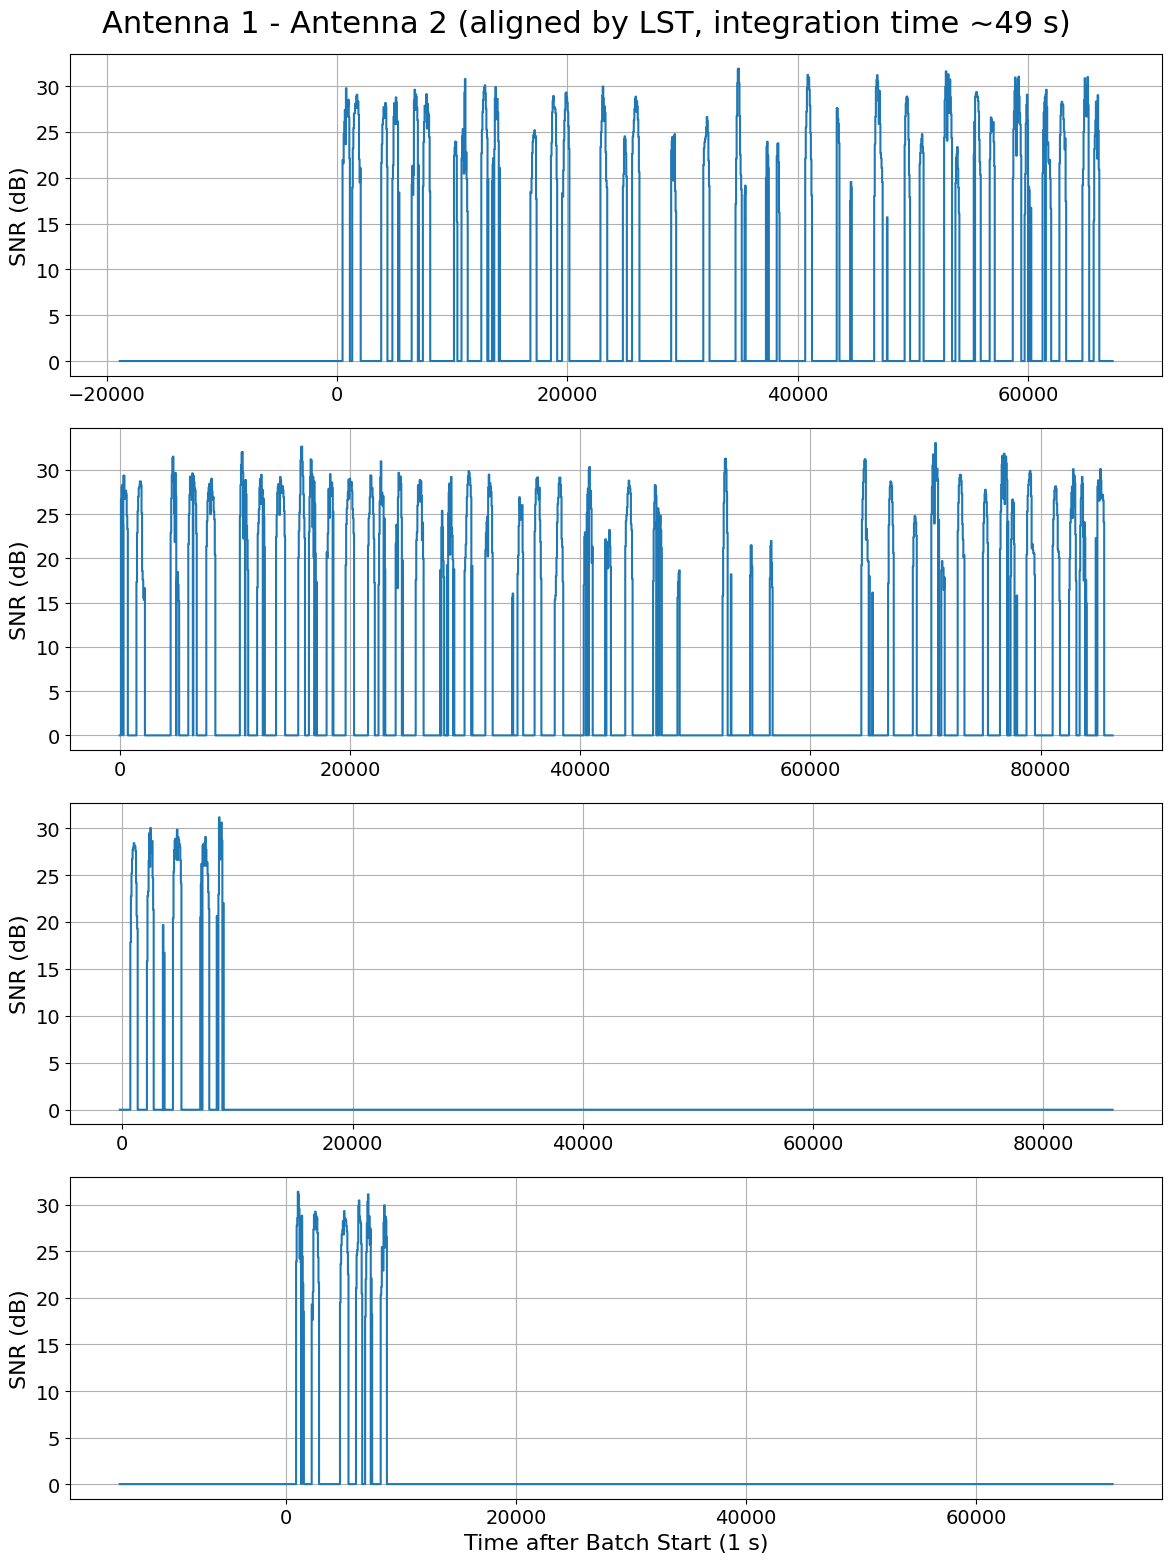

In [ ]:
importlib.reload(su)
bsecs, btimes, fig4 = su.snr_times_many(
    [bpath1, bpath2, bpath3, bpath4], 
    [bstart1, bstart2, bstart3, bstart4], 
    [bend1, bend2, bend3, bend4], 
    ant_name)

Here, the last two batches actually occurr on the same day due to an interruption. In total, we therefore have parts of three days of data.

# PART 2 Timing Discrepancies

## i) Get high SNR pulses

The first thing we want when trying to fit for a UTC-Spectrum map is to isolate high SNR regions where the fit is most likely to not suck. Since we have reasonably high resolution in SNR with time, we can find timestamps where we know a certain sat is risen at high SNR.

In [ ]:
def get_windows_oneant(json_path, 
                       batch_start, 
                       ant,
                       min_SNR,
                       min_nchunks,
                       max_nchunks=None,
                       interval=None
                       ):

    windows = []
    data = su.load_json(json_path)[f'{batch_start}']
    ant_data = data[ant]

    for pulse in ant_data:
        t0, t1 = pulse["times"]
        if interval is not None:
            int_start = batch_start + interval[0]
            int_end   = batch_start + interval[1]
            if t1<int_start or t0>int_end:
                continue

        chunks = pulse["SNR, Chan, Sat"]
        if not chunks:
            continue

        snrs  = np.array([c[0] for c in chunks])
        chans = np.array([c[1] for c in chunks])
        sats  = np.array([c[2] for c in chunks])

        nchunks = len(snrs)
        chunk_dt = (t1 - t0) / nchunks

        above = snrs > min_SNR

        # ---------------------------------------------
        # Find contiguous True segments
        # ---------------------------------------------
        segments = []
        start = None

        for i, flag in enumerate(above):
            if flag:
                if start is None:
                    start = i
            else:
                if start is not None:
                    segments.append((start, i))
                    start = None

        if start is not None:
            segments.append((start, len(above)))

        if not segments:
            continue

        best_global_mean = -np.inf
        best_start = None
        best_len = 0

        # ---------------------------------------------
        # Evaluate each segment
        # ---------------------------------------------
        for s, e in segments:
            seg_len = e - s

            if seg_len < min_nchunks:
                continue

            segment_snrs = snrs[s:e]

            # Case 1: no max limit → take whole segment
            if max_nchunks is None or seg_len <= max_nchunks:
                seg_mean = segment_snrs.mean()

                if seg_mean > best_global_mean:
                    best_global_mean = seg_mean
                    best_start = s
                    best_len = seg_len

            else:
                # Case 2: need best subwindow of length max_nchunks
                k = max_nchunks

                # cumulative sum for fast sliding mean
                csum = np.cumsum(segment_snrs)
                csum = np.insert(csum, 0, 0)

                # compute window sums
                window_sums = csum[k:] - csum[:-k]
                idx = np.argmax(window_sums)

                seg_mean = window_sums[idx] / k

                if seg_mean > best_global_mean:
                    best_global_mean = seg_mean
                    best_start = s + idx
                    best_len = k

        if best_start is None:
            continue
        end_idx = best_start + best_len

        t_start = int(t0 + best_start * chunk_dt)
        t_end = int(t0 + end_idx * chunk_dt)

        windows.append({
            "antenna": ant,
            "sat": int(sats[best_start]),
            "channel": int(chans[best_start]),
            "t_start": t_start,
            "t_end": t_end,
            "len": t_end - t_start
        })
    return windows

In [ ]:
def get_joint_windows(json_path,
                      batch_start,
                      antennas,
                      min_SNR,
                      min_nchunks,
                      max_nchunks=None,
                      interval=None):
    """
    Compute overlapping windows across multiple antennas,
    including satID and channel information.

    Returns:
        List of dicts with t_start, t_end, sat, channel
    """

    # 1) Collect windows per antenna
    windows_by_ant = {}
    for ant in antennas:
        windows_by_ant[ant] = get_windows_oneant(
            json_path=json_path,
            batch_start=batch_start,
            ant=ant,
            min_SNR=min_SNR,
            min_nchunks=min_nchunks,
            max_nchunks=max_nchunks,
            interval=interval
        )

    ants = list(windows_by_ant.keys())
    if not ants:
        return []

    # Sort each antenna's windows by start time
    for ant in ants:
        windows_by_ant[ant] = sorted(
            windows_by_ant[ant],
            key=lambda w: w["t_start"]
        )

    # Initialize indices for each antenna
    indices = {ant: 0 for ant in ants}
    joint_overlaps = []

    while True:
        # Stop if any antenna is exhausted
        if any(indices[ant] >= len(windows_by_ant[ant]) for ant in ants):
            break

        current_windows = [
            windows_by_ant[ant][indices[ant]]
            for ant in ants
        ]

        # Compute intersection
        max_start = max(w["t_start"] for w in current_windows)
        min_end   = min(w["t_end"] for w in current_windows)

        if max_start < min_end:
            # Determine which antenna limits the overlap (earliest end)
            earliest_end_ant = min(
                ants,
                key=lambda ant: windows_by_ant[ant][indices[ant]]["t_end"]
            )
            limiting_window = windows_by_ant[earliest_end_ant][indices[earliest_end_ant]]

            joint_overlaps.append({
                "t_start": int(max_start),
                "t_end": int(min_end),
                "sat": int(limiting_window["sat"]),
                "channel": int(limiting_window["channel"]),
                "len": int(min_end) - int(max_start)
            })

        # Advance the antenna whose window ends earliest
        earliest_end_ant = min(
            ants,
            key=lambda ant: windows_by_ant[ant][indices[ant]]["t_end"]
        )
        indices[earliest_end_ant] += 1

    return joint_overlaps


In [ ]:
w_all = get_windows_oneant(bpath1, 
                        bstart1, 
                        "Antenna 2",
                        300, #min SNR
                        4,  #min number of chunks
                        max_nchunks=None,
       #                 interval=[6e4, 9e4]  #seconds in batch time you can look at
                        )

print(len(w_all)) 
for p in w_all:
    print(p)

26
{'antenna': 'Antenna 2', 'sat': 25338, 'channel': 7, 't_start': 1753133579, 't_end': 1753133824, 'len': 245}
{'antenna': 'Antenna 2', 'sat': 33591, 'channel': 16, 't_start': 1753134223, 't_end': 1753134714, 'len': 491}
{'antenna': 'Antenna 2', 'sat': 59051, 'channel': 3, 't_start': 1753136743, 't_end': 1753137136, 'len': 393}
{'antenna': 'Antenna 2', 'sat': 57166, 'channel': 3, 't_start': 1753137712, 't_end': 1753138105, 'len': 393}
{'antenna': 'Antenna 2', 'sat': 25338, 'channel': 7, 't_start': 1753139485, 't_end': 1753139829, 'len': 344}
{'antenna': 'Antenna 2', 'sat': 33591, 'channel': 16, 't_start': 1753140361, 't_end': 1753140803, 'len': 442}
{'antenna': 'Antenna 2', 'sat': 25338, 'channel': 7, 't_start': 1753145388, 't_end': 1753145830, 'len': 442}
{'antenna': 'Antenna 2', 'sat': 33591, 'channel': 16, 't_start': 1753146514, 't_end': 1753146809, 'len': 295}
{'antenna': 'Antenna 2', 'sat': 25338, 'channel': 7, 't_start': 1753151488, 't_end': 1753151832, 'len': 344}
{'antenna': '

Once we have these timestamps, we lock in the start and end times. These are used for identification of the pulse from here on out. Moreover, for consistency, we save all the relavant information into the 'data' folder in a json for ease of identification of all our pulses.

In [ ]:
#dump pulses
#DONT TOUCH IT WILL OVERWRITE PULSES

# path_pulses = f'/scratch/thomasb/batch_{bstart1}/data/pulses.json'
# with open(path_pulses, "w") as f:
#         json.dump(w_all, f, indent=2)

## ii) Cutting Data

We compute the upsampled data corresponding to each pulse for each antenna (around the detection channel), but still need to cut the data properly for fitting.

## iii) After Fit

We now want to determine the actual map from our fitted values and starting spectra.

In [6]:
#mapping batch 1
path_map1 = f'/scratch/thomasb/batch_{bstart1}/timing_discrepancies/times_all.json'
with open(path_map1, "r") as f:
        map1 = json.load(f)

#mapping batch 2
path_map2 = f'/scratch/thomasb/batch_{bstart2}/timing_discrepancies/times_all.json'
with open(path_map2, "r") as f:
        map2 = json.load(f)

# path_map2 = f'/scratch/thomasb/batch_{bstart2}/timing_discrepancies/times_all_coherent.json'
# with open(path_map2, "r") as f:
#         map2 = json.load(f)

In [8]:
utc_corr1, spectra_uncorr1 = [], []
utc_corr2, spectra_uncorr2 = [], []

for fname, pulse in map1.items():
    if 'offset_fitted' in pulse.values():
        utc_corr1.append(pulse['offset_fitted']/1000 + pulse["pulse_start_ts"])
        spectra_uncorr1.append(pulse["start_specnum"])

for fname, pulse in map2.items():
    if 'offset_fitted' in pulse.values():
        utc_corr2.append(pulse['offset_fitted']/1000 + pulse["pulse_start_ts"])
        spectra_uncorr2.append(pulse["start_specnum"])

In [25]:
spectra_corr1 = hd.correct_overflow(spectra_uncorr1)
utc_corr1 = np.array(utc_corr1)

spectra_corr2 = hd.correct_overflow(spectra_uncorr2)
utc_corr2 = np.array(utc_corr2)

In [9]:
#choose batch 2
spectra_corr, utc_corr = spectra_corr2, utc_corr2

NameError: name 'spectra_corr2' is not defined

In [10]:
m,c = np.polyfit(spectra_corr, utc_corr, 1)
print('Seconds per spectra', m)
print('Initial UTC time:', c)
plt.scatter(spectra_corr, utc_corr, c='r')
plt.plot(spectra_corr, m*spectra_corr + c, c='b')
plt.xlabel('Spectrum Number (adjusted for overflow)')
plt.ylabel('UTC Time (s)')

NameError: name 'spectra_corr' is not defined

Standard deviation of residuals: 0.08835465897643403 secs


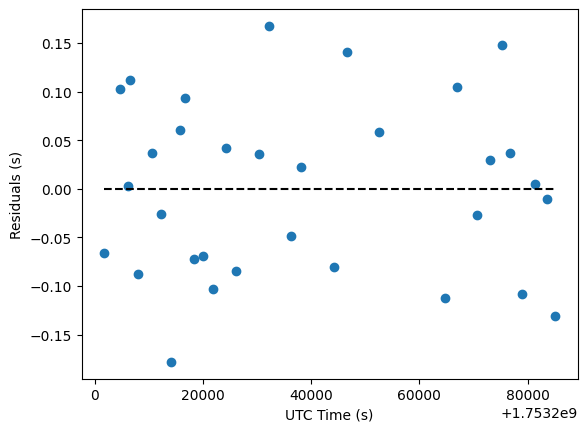

In [28]:
res = np.asarray(utc_corr)-m*np.asarray(spectra_corr)-c
plt.scatter(utc_corr, res)
plt.xlabel('UTC Time (s)')
plt.ylabel('Residuals (s)')
plt.hlines(y=0,xmin=np.min(utc_corr), xmax=np.max(utc_corr),color='black',linestyle='--')
print(f'Standard deviation of residuals: {np.std(res)} secs')

In [29]:
res_MAD = hd.get_MAD(res)
print(f"Residual MAD: {res_MAD}")

Residual MAD: 0.07415461540222168


In [30]:
cov = hd.get_prediction_error(res, spectra_corr)

pred_var = np.diag(cov)
pred_error = np.sqrt(pred_var)
print(pred_error)
print('Error on UTC given a spectrum number:', np.mean(pred_error))

0.008058369819707823
[0.02653836 0.02523867 0.02453964 0.02439048 0.02373624 0.02266277
 0.02199915 0.02129999 0.02065237 0.02035065 0.01972828 0.0192294
 0.01862105 0.01792672 0.01748554 0.0166113  0.01632906 0.0159404
 0.01587382 0.01616668 0.01647251 0.01771582 0.02168876 0.02261782
 0.02417622 0.02518124 0.0261891  0.02687098 0.0279495  0.02902821
 0.03016302 0.0308694 ]
Error on UTC given a spectrum number: 0.022007598483926777


# PART 3 Fine Timing

## i) Recut Pulse

More strict with cut in fine timing. Need high SNR.

## ii) Get full Solution

Once we fit for everything, we extract the data and get the full timing solution. For the time being it's done only for russian satellites, and the taus are averaged across the pulse.

In [53]:
with open(os.path.join(f'/scratch/thomasb/batch_{bstart2}/timing_discrepancies/times_all.json'), "r") as f:
        dict_fits_discrep = json.load(f)
UTC_per_spec = dict_fits_discrep['fit']['UTC_per_spec']
UTC_offset = dict_fits_discrep['fit']['UTC_offset']

map_blines = {0:'MARS 1-2', 1:'MARS 1-4', 2:'MARS 1-5', 3:'MARS 1-6', 4:'MARS 1-7', 5:'MARS 1-8'}

acclen = 1024
osamp = 64

In [54]:
fnames_all = []
fnames_russian = []

path_pulses = f'/scratch/thomasb/batch_{bstart2}/data/pulses.json'
with open(path_pulses, "r") as f:
    pulses = json.load(f)

for p_idx in range(len(pulses)):
    pulse = pulses[p_idx]
    pulse_start_ts,pulse_end_ts=pulse['t_start'],pulse['t_end']
    chan_det = pulse['channel']
    if chan_det%2 == 0:
        chans_old = np.arange(chan_det-2, chan_det+2) + 1834
    else:
        chans_old = np.arange(chan_det-1, chan_det+3) + 1834
    fname = f"data_raw_osamp=64_start={pulse_start_ts}_end={pulse_end_ts}_chans={chans_old[0]}:{chans_old[-1]}.npy"
    fnames_all.append(fname)
    
    satID = int(pulse['sat'])
    if satID in {59051, 57166}:
        fnames_russian.append(fname)

In [56]:
taus = {}
taus_full = {}
stds = {}
errs = {}
spectra = []
for bline in map_blines.values():
    taus[bline] = []
    taus_full[bline] = []
    stds[bline] = []
    errs[bline] = []

#with h5py.File(f'/scratch/thomasb/batch_{bstart1}/fine_timing/timing_solution.h5', 'r') as f:
with h5py.File(f'/scratch/thomasb/batch_{bstart2}/fine_timing/timing_solution_15may.h5', 'r') as f:
    for name in fnames_russian:
        spectra.append(f[name]['taus'].attrs['starting_specnum'])
        #spectra_all[name] = np.arange(start_spectrum, start_spectrum + nvis*acclen*osamp, acclen*osamp)
        taus_all_file = f[name]['taus'][:]
        errs_all_file = f[name]['errs'][()]
        for i, bline in map_blines.items():
            taus[bline].append(np.mean(taus_all_file[i,:]))  #taking average across it for now
            taus_full[bline].append(taus_all_file[i,:])
            errs[bline].append(errs_all_file[i])
            stds[bline].append(np.std(taus_all_file[i,:]))   #std across pulse
        
spectra = np.array(spectra)
for bline in map_blines.values():
    taus[bline] = np.array(taus[bline])
    stds[bline] = np.array(stds[bline])

In [57]:
# taus_dict = {}
# for pidx, pulse in enumerate(fnames_russian):
#     utc_start = int(UTC_per_spec*spectra[pidx]+UTC_offset)
#     taus_dict[utc_start] = np.zeros((len(map_blines), 120))
#     for bidx, bname in map_blines.items():
#         taus_dict[utc_start][bidx, :] = taus_full[bname][pidx]
    
# with open("data.txt", "w") as f:
#     f.write(str(taus_dict))
# print(taus_dict[1753204687])

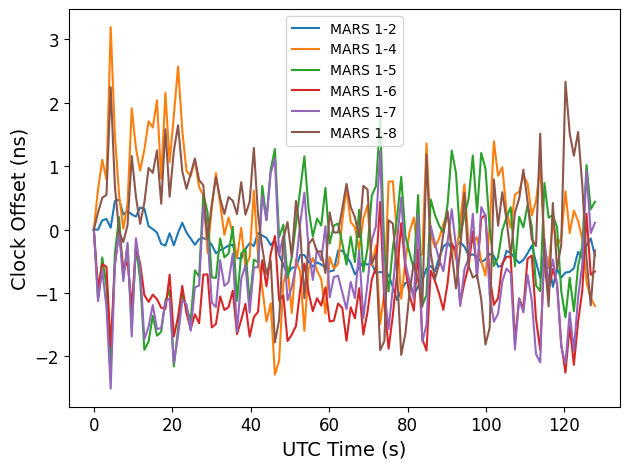

In [58]:
pidx = 0
for bidx in range(len(map_blines)):
    taus1 = taus_full[map_blines[bidx]][pidx]
    taus1 = taus1 - taus1[0]
    times1 = np.arange(len(taus1)) * 4096*osamp*acclen/250e6
    plt.plot(times1, taus1, label=map_blines[bidx])
    plt.xlabel('UTC Time (s)')
    plt.ylabel('Clock Offset (ns)')
    plt.legend()
    plt.tight_layout()

In [59]:
print(errs['MARS 1-2'][0])

4.372404452881256


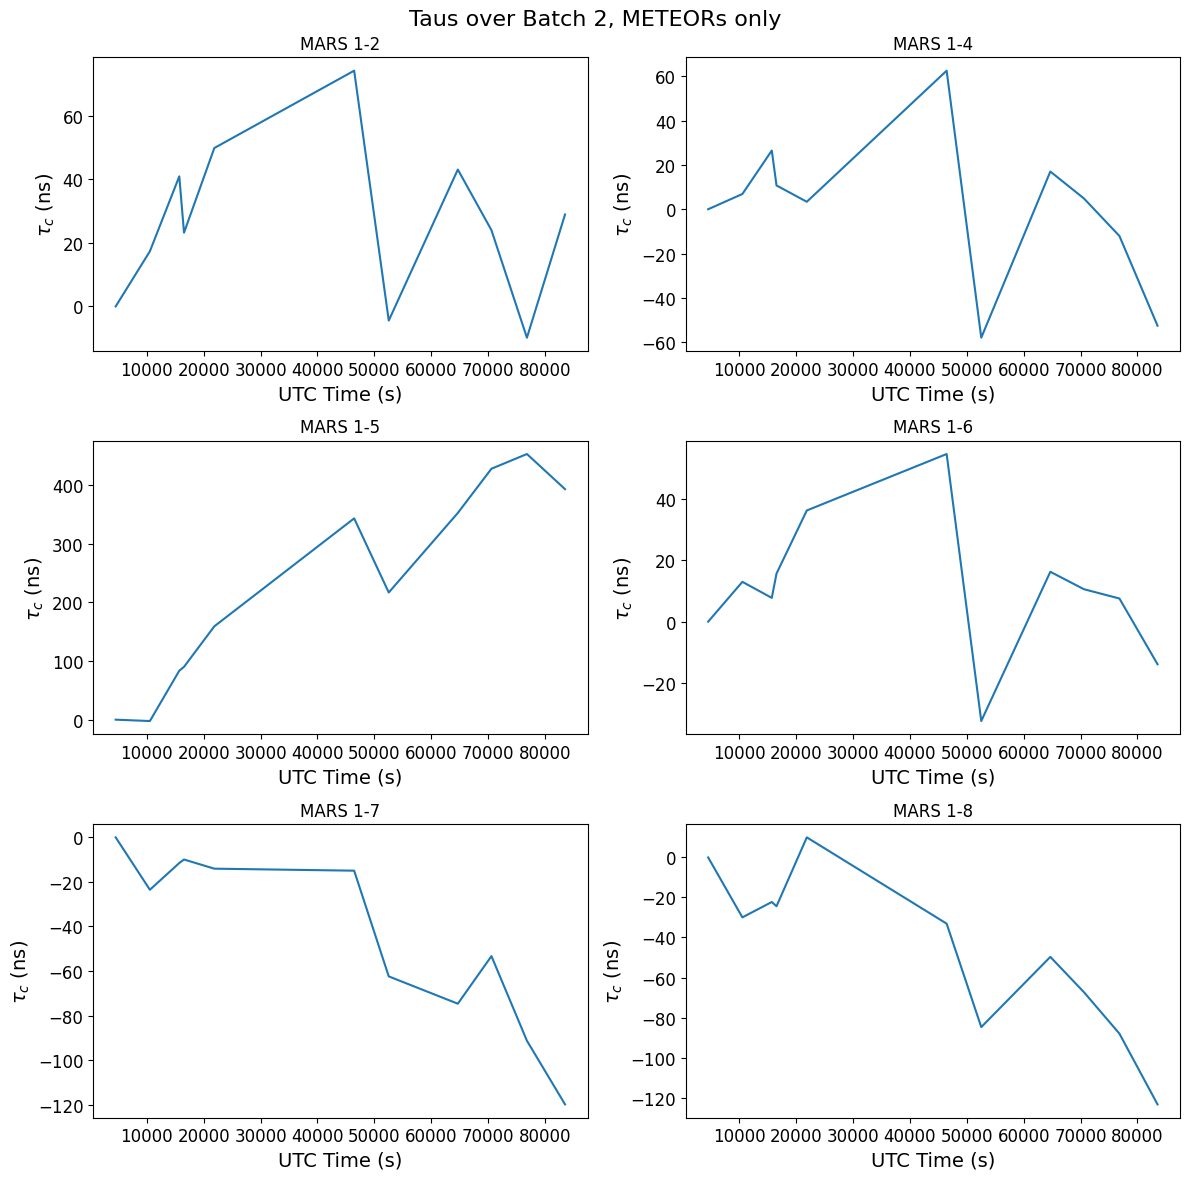

In [60]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.suptitle('Taus over Batch 2')
ax=np.ravel(ax)
pnum=0
#fig.suptitle()
times = spectra*UTC_per_spec + UTC_offset
for i in range(6):
    ax[pnum].set_ylabel(r'$\tau_c$ (ns)')
    ax[pnum].set_xlabel('UTC Time (s)')
    ax[pnum].set_title(map_blines[pnum])
    ax[pnum].plot(times- bstart2, taus[map_blines[pnum]]-taus[map_blines[pnum]][0])
    #ax[pnum].set_xlim(0, 50000)
    pnum+=1

fig.suptitle('Taus over Batch 2, METEORs only', fontsize=16)
fig.tight_layout()

[np.float64(4.372404452881256), np.float64(3.88040985228195), np.float64(3.665942208721845), np.float64(5.170345412912666), np.float64(5.655413978197498), np.float64(12.609362335479458), np.float64(5.441263445142445), np.float64(3.617347738361367), np.float64(4.330535358469506), np.float64(3.970838396013818), np.float64(9.078440552523984)]
[np.float64(6.546022878551634), np.float64(5.804871755297657), np.float64(4.292551362794775), np.float64(7.070777445405138), np.float64(6.63144499613082), np.float64(18.586200514808414), np.float64(7.597846681418295), np.float64(4.512631661975684), np.float64(7.731930409913427), np.float64(4.896907179472602), np.float64(19.766230576501602)]
[np.float64(4.9633884909899715), np.float64(4.569862839158214), np.float64(3.559030428476679), np.float64(4.809404638268226), np.float64(4.445043933468473), np.float64(11.714682274409556), np.float64(5.700017624449425), np.float64(3.436306421153514), np.float64(5.383685990237172), np.float64(3.3467810203735855), n

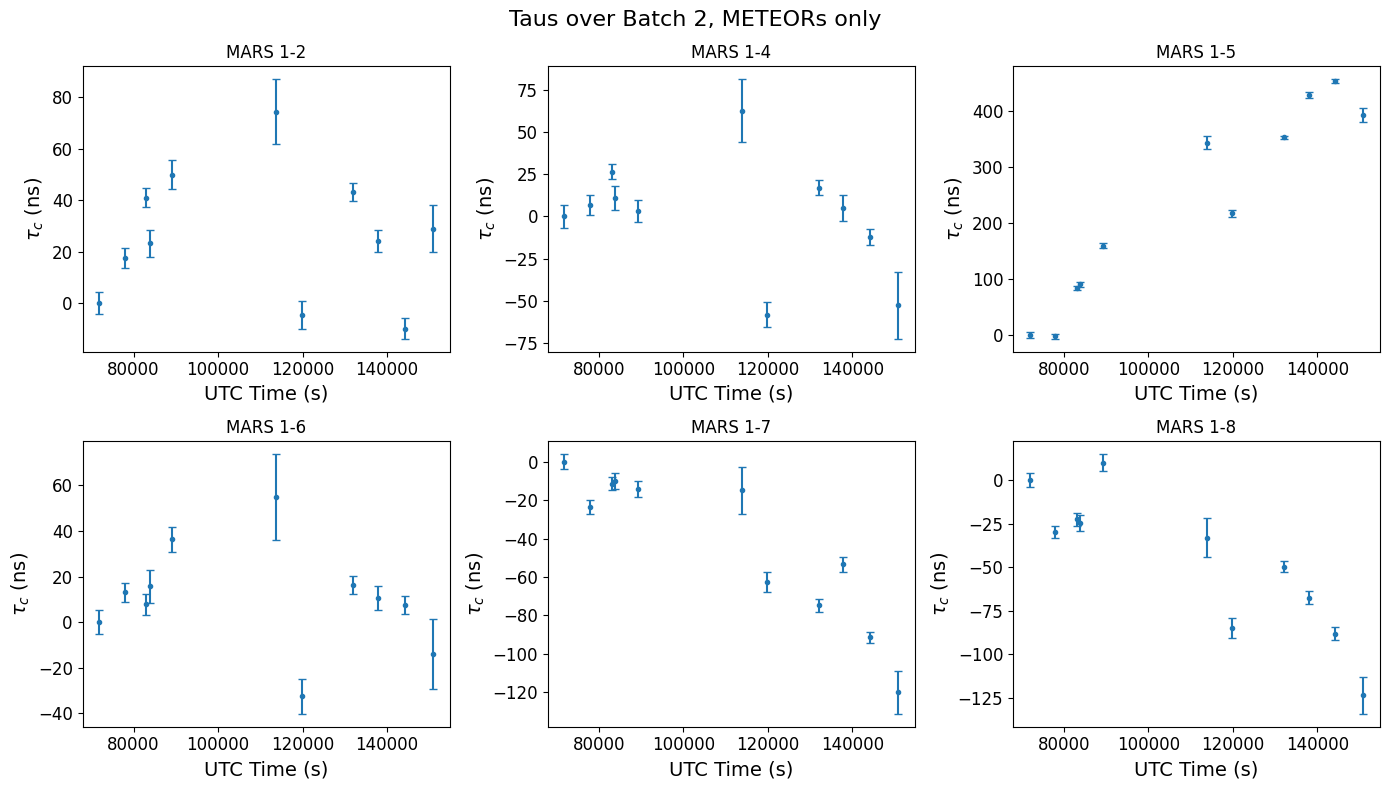

In [61]:
fig, ax = plt.subplots(2, 3, figsize=(14, 8))

plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

ax = np.ravel(ax)

times = spectra * UTC_per_spec + UTC_offset

pnum = 0

for i in range(6):

    y = taus[map_blines[pnum]] - taus[map_blines[pnum]][0]
    yerr = errs[map_blines[pnum]]   # your uncertainties
    print(yerr)

    ax[pnum].set_ylabel(r'$\tau_c$ (ns)')
    ax[pnum].set_xlabel('UTC Time (s)')
    ax[pnum].set_title(map_blines[pnum])

    ax[pnum].errorbar(
        times - bstart1,
        y,
        yerr=yerr,
        fmt='o',
        markersize=3,
        capsize=3,
        linestyle='none'
    )

    pnum += 1

fig.suptitle('Taus over Batch 2, METEORs only', fontsize=16)
fig.tight_layout()

In [62]:
import numpy as np

np.set_printoptions(formatter={'float_kind': '{:f}'.format})

print(np.array(times))

[1753204687.977176 1753210702.401971 1753215871.263777 1753216701.961237
 1753222027.748531 1753246608.920531 1753252692.737518 1753264834.057091
 1753270743.222690 1753276981.059755 1753283679.279608]


In [63]:
for bline in map_blines.values():
    print(bline, taus[bline])

MARS 1-2 [-3055.917916 -3038.554365 -3014.942802 -3032.686488 -3006.020426
 -2981.647672 -3060.376281 -3012.794800 -3031.894782 -3065.781913
 -3026.961088]
MARS 1-4 [-21417.008647 -21410.121739 -21390.489831 -21406.261396 -21413.638016
 -21354.408563 -21475.045400 -21399.976476 -21412.136029 -21429.088764
 -21469.626622]
MARS 1-5 [7768.628358 7766.300098 7852.093865 7858.683196 7927.693328 8111.654587
 7985.366210 8120.938151 8196.280921 8221.362575 8161.489761]
MARS 1-6 [-3635.467621 -3622.453202 -3627.695111 -3619.754293 -3599.104682
 -3580.646997 -3667.975598 -3619.160966 -3624.862560 -3627.905724
 -3649.399545]
MARS 1-7 [-4093.319290 -4116.852149 -4104.846540 -4103.267515 -4107.384609
 -4108.285031 -4155.757410 -4168.019402 -4146.652183 -4184.649151
 -4213.224278]
MARS 1-8 [8420.456205 8390.515270 8398.184872 8396.061393 8430.497290 8387.367538
 8335.674198 8370.755613 8353.124364 8332.399239 8297.053078]


In [64]:
for bline in map_blines.values():
    print(bline, np.array(errs[bline], dtype='float'))

MARS 1-2 [4.372404 3.880410 3.665942 5.170345 5.655414 12.609362 5.441263 3.617348
 4.330535 3.970838 9.078441]
MARS 1-4 [6.546023 5.804872 4.292551 7.070777 6.631445 18.586201 7.597847 4.512632
 7.731930 4.896907 19.766231]
MARS 1-5 [4.963388 4.569863 3.559030 4.809405 4.445044 11.714682 5.700018 3.436306
 5.383686 3.346781 12.121245]
MARS 1-6 [5.161955 4.294404 4.557140 7.350188 5.472637 18.785976 7.684185 4.030601
 5.310124 3.935684 15.212998]
MARS 1-7 [3.830984 3.490958 3.427417 4.278226 4.133769 12.125365 5.180358 3.239159
 3.997830 2.985824 11.214660]
MARS 1-8 [3.891728 3.414195 3.721513 4.542830 4.838981 11.183151 5.584126 3.171321
 3.958717 3.695674 10.660094]


In [65]:
for bline in map_blines.values():
    print(bline, stds[bline])

MARS 1-2 [0.312789 0.519389 0.223798 0.291445 0.180877 0.253807 0.270511 0.166498
 0.394202 0.222175 0.402427]
MARS 1-4 [0.919602 0.742578 2.181874 1.057030 3.717733 1.193373 1.244331 2.601070
 1.563675 7.939865 8.385727]
MARS 1-5 [0.776486 0.872037 0.574367 1.012935 0.645415 0.772611 2.862462 1.017286
 0.654964 2.012618 9.411411]
MARS 1-6 [0.537679 0.510144 2.589355 0.958996 2.309366 0.416418 1.124158 1.051366
 0.598796 3.115717 4.267510]
MARS 1-7 [0.722665 0.858531 0.690486 1.005976 0.524073 0.813099 3.045565 0.429795
 0.699867 1.001412 11.330975]
MARS 1-8 [0.852775 0.692322 3.223838 1.017293 1.009889 0.778489 1.095996 1.273411
 1.456740 4.830325 8.940373]


In [44]:
#EXAMPLE USAGE

# mapping index to baselines
map_blines = {0:'MARS 1-2', 1:'MARS 1-4', 2:'MARS 1-5', 3:'MARS 1-6', 4:'MARS 1-7', 5:'MARS 1-8'}

#spectra, taus, noise, fit errors
s, t, n, e = {}, {}, {}, {}

#opening everything up
with h5py.File('/scratch/thomasb/batch_1753200150/fine_timing/finetiming_dump_russians_batch2.h5', 'r') as f:
    for name in russian_fnames:
        s[name] = f[name]['spectra'][:]
        t[name], n[name], e[name] = {}, {}, {}
        for i, bline in map_blines.items():
            t[name][bline] = f[name][f'taus_{bline}'][:]
            e[name][bline] = f[name][f'errs_{bline}']
            n[name][bline] = f[name][f'noise_{bline}'][:]

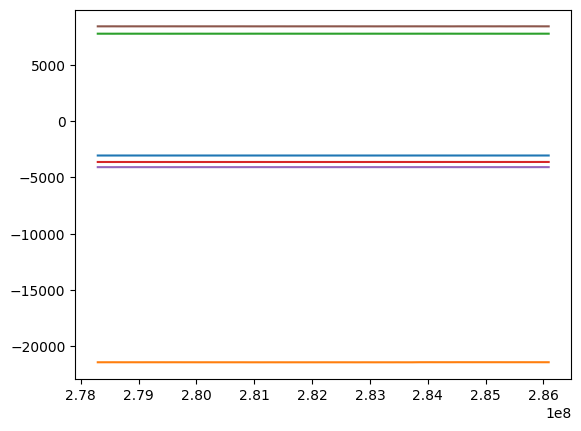

In [43]:
for i, bline in map_blines.items():
    plt.plot(s[russian_fnames[0]], t[russian_fnames[0]][bline])

In [17]:
spectra_all_unsorted = np.concatenate(spectra)
taus_all_unsorted = np.concatenate(taus, axis=1)
errors_all = np.array(errors).T
start_spectra = np.array(start_spectra)

print(spectra_all_unsorted.shape)
print(taus_all_unsorted.shape)
print(errors_all.shape)

sort_idx = np.argsort(spectra_all_unsorted)
print(np.diff(sort_idx))
spectra_all = spectra_all_unsorted[sort_idx]
times_all = spectra_all * m + c
start_times = start_spectra * m + c
taus_all = taus_all_unsorted[:, sort_idx]  

print(start_times.shape)

RuntimeError: Unable to synchronously get dataspace (invalid dataset identifier)

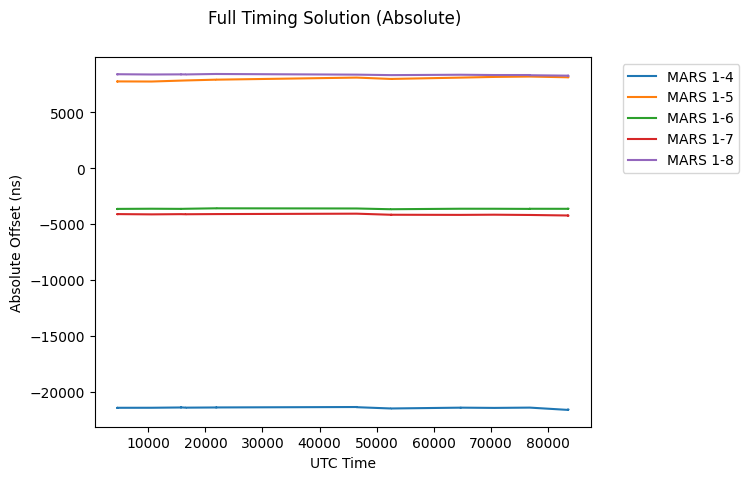

In [57]:
nbl = taus_all.shape[0]
map = {0:'MARS 1-4', 1:'MARS 1-5', 2:'MARS 1-6', 3:'MARS 1-7', 4:'MARS 1-8'}
for i in range(nbl):
    plt.plot(times_all-c, taus_all[i,:], label = map[i])

plt.suptitle('Full Timing Solution (Absolute)')
plt.xlabel('UTC Time')
plt.ylabel('Absolute Offset (ns)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

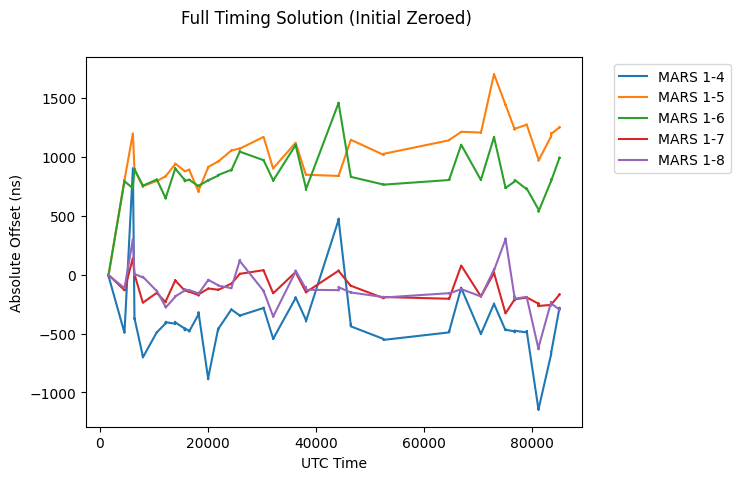

In [ ]:
nbl = taus_all.shape[0]
map = {0:'MARS 1-4', 1:'MARS 1-5', 2:'MARS 1-6', 3:'MARS 1-7', 4:'MARS 1-8'}
for i in range(nbl):
    plt.plot(times_all -c , taus_all[i,:]- taus_all[i,0], label = map[i])

plt.suptitle('Full Timing Solution (Initial Zeroed)')
plt.xlabel('UTC Time')
plt.ylabel('Absolute Offset (ns)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

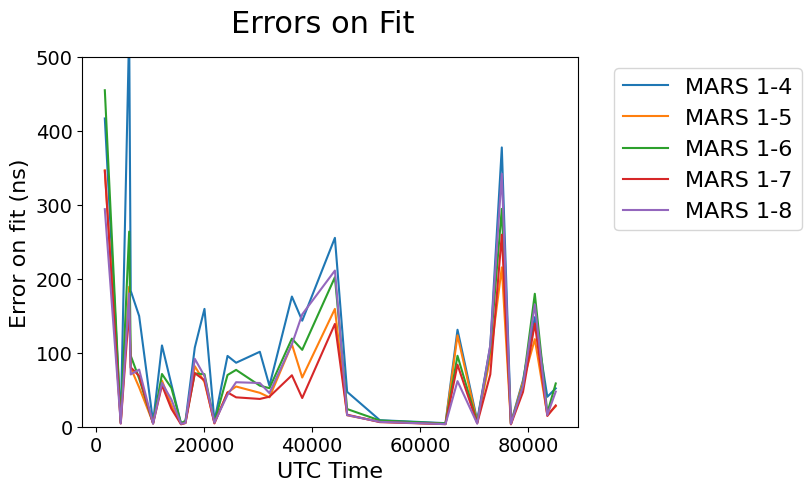

In [ ]:
nbl = taus_all.shape[0]
map = {0:'MARS 1-4', 1:'MARS 1-5', 2:'MARS 1-6', 3:'MARS 1-7', 4:'MARS 1-8'}
for i in range(nbl):
    plt.plot(start_times-c , errors_all[i, :], label = map[i])


plt.suptitle('Errors on Fit')
plt.xlabel('UTC Time')
plt.ylabel('Error on fit (ns)')
plt.ylim(0, 500)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

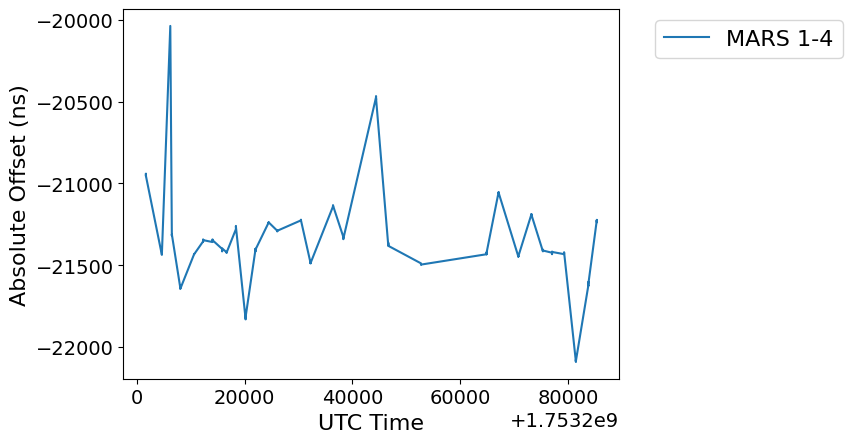

In [ ]:
index = 0
plt.plot(times_all, taus_all[index,:], label = map[index])

plt.xlabel('UTC Time')
plt.ylabel('Absolute Offset (ns)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# (Optional) Coherence Analysis

In [ ]:
ratios_all_mean = []
ratios_all = []
with h5py.File('/scratch/thomasb/batch_1753200150/coherence/coherence_ratios.h5', 'r') as f:
    for fname in fnames:
        if fname in f:
            ratios = f[fname]['ratios'][:]
            ratios_all.append(ratios)
            ratios_mean = np.mean(ratios, axis = 1)
            ratios_all_mean.append(ratios_mean)

ratios_all = np.array(ratios_all)
print(ratios_all.shape)
ratios_all_mean = np.array(ratios_all_mean)
print(ratios_all_mean.shape)

(11, 15, 80)
(11, 15)


In [ ]:
from itertools import combinations
ant_idxs = [0,2,3,4,5,6]
bls = list(combinations(ant_idxs, 2))
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
labels = [f"{antmap[i]}-{antmap[j]}" for i, j in bls]
print(labels)

['MARS1-MARS4', 'MARS1-MARS5', 'MARS1-MARS6', 'MARS1-MARS7', 'MARS1-MARS8', 'MARS4-MARS5', 'MARS4-MARS6', 'MARS4-MARS7', 'MARS4-MARS8', 'MARS5-MARS6', 'MARS5-MARS7', 'MARS5-MARS8', 'MARS6-MARS7', 'MARS6-MARS8', 'MARS7-MARS8']


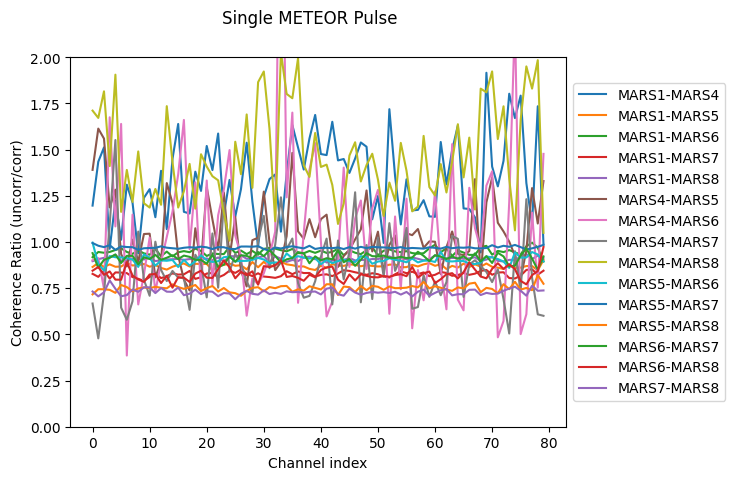

In [ ]:
for i in range(ratios_all.shape[1]):
    plt.plot(ratios_all[5, i, :], label=labels[i])
    #print(ratios_all[0, i, :].shape)
plt.xlabel('Channel index')
plt.ylim(0, 2)
plt.ylabel('Coherence Ratio (uncorr/corr)')
plt.suptitle('Single METEOR Pulse')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

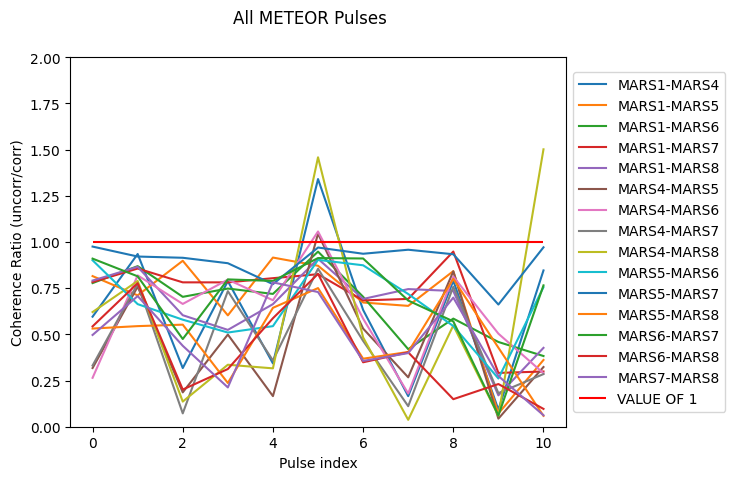

In [ ]:
for i in range(ratios_all_mean.shape[1]):
    plt.plot(ratios_all_mean[:, i], label=labels[i])
plt.xlabel('Pulse index')
plt.ylim(0, 2)
plt.ylabel('Coherence Ratio (uncorr/corr)')
plt.hlines(y=1, xmax=ratios_all_mean.shape[0]-1, xmin=0, color='red', label='VALUE OF 1')
plt.suptitle('All METEOR Pulses')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

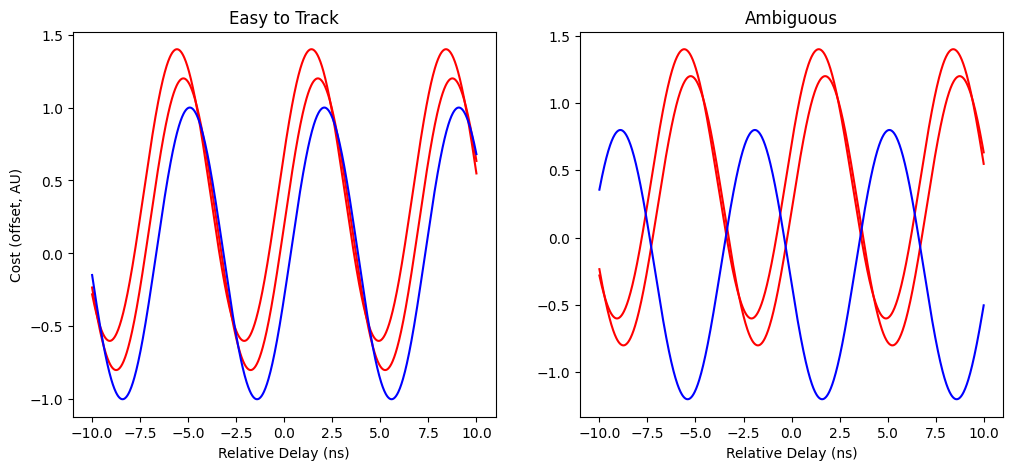

In [10]:
import numpy as np
import matplotlib.pyplot as plt

taus = np.linspace(-10,10, 1001)
sine1 = np.sin(2*np.pi*(taus/7)+0.3)+0.4
sine2 = np.sin(2*np.pi*(taus/7))+0.2

sine3 = np.sin(2*np.pi*(taus/7)-0.3)
sine4 = np.sin(2*np.pi*(taus/7)-3)-0.2

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(taus, sine1, c='r')
ax[0].plot(taus, sine2, c='r')
ax[0].plot(taus, sine3, c='b')
ax[0].set_xlabel('Relative Delay (ns)')
ax[0].set_ylabel('Cost (offset, AU)')
ax[0].set_title('Easy to Track')

ax[1].plot(taus, sine1, c='r')
ax[1].plot(taus, sine2, c='r')
ax[1].plot(taus, sine4, c='b')
ax[1].set_xlabel('Relative Delay (ns)')
ax[1].set_title('Ambiguous')

fig.savefig('./images/peak_tracking.png')